In [1]:
import joblib
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
X_train, X_test, y_train, y_test = joblib.load("data/train_test_split.pkl")

preprocessor = joblib.load("data/preprocessor.pkl")

X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

In [3]:
rf = RandomForestClassifier(random_state=42)

start = time.time()
tracemalloc.start()

rf.fit(X_train, y_train)

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
train_time = time.time() - start

start_pred = time.time()
y_pred = rf.predict(X_test)
predict_time = time.time() - start_pred

In [4]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("Baseline Performance:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Training Time: {train_time:.4f}s")
print(f"Prediction Time: {predict_time:.4f}s")
print(f"Peak Memory: {peak / 1024:.2f} KB")

Baseline Performance:
Precision: 0.7360
Recall: 0.6166
F1 Score: 0.6710
ROC-AUC: 0.9022
Training Time: 1.8714s
Prediction Time: 0.0773s
Peak Memory: 11976.63 KB


In [5]:
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Best Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [6]:
y_pred_best = best_model.predict(X_test)

precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])

print("\nTuned Model Performance:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")


Tuned Model Performance:
Precision: 0.7434
Recall: 0.6201
F1 Score: 0.6762
ROC-AUC: 0.9093


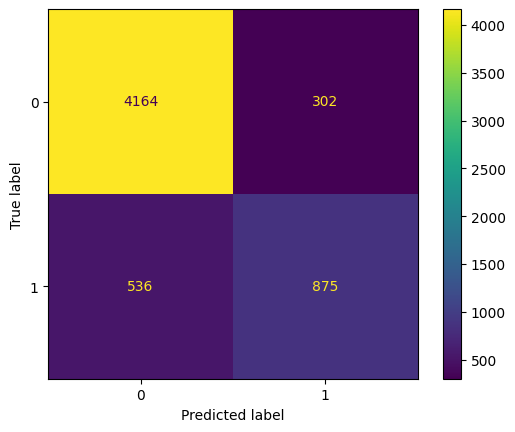

In [7]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

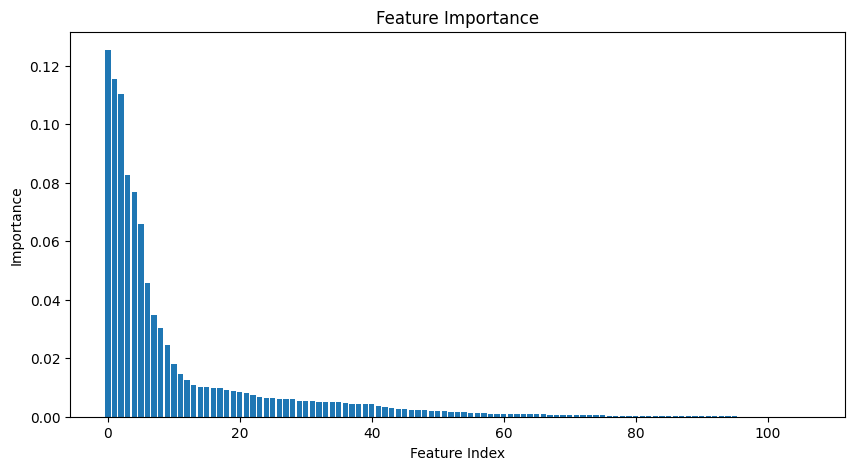

In [8]:
importances = best_model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()

In [9]:
joblib.dump(best_model, "data/rf_model.pkl")

['data/rf_model.pkl']